In [1]:
import pandas as pd

In [4]:
!pip install matplotlib seaborn

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
     --- --------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
     --- --------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
     --- --------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
     --- --------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
     ------ ------------------------------ 51.2/294.9 kB 154.6 kB/s eta 0:00:02
     ------- ----------------------------- 61.4/294.9 kB 173.0 kB/s eta 0:00:02
     -------- ---------------------------- 71.7/294.9 kB 196.9 kB/s eta 0:00:02
     ------------- ---------------------- 112.6/294.9 kB 273.1 kB/s eta 0:00:01
     ------------- ---------------------- 112.6/294.9 kB 273.1 kB/s eta 0:00:01
     -------------- --------------------- 122.9/294.9 kB 232.7 kB


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.simplefilter("ignore")

In [3]:
df=pd.read_csv('train.csv')

df.drop(columns=['Unnamed: 0','Booking_ID'],axis=1,inplace=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


In [4]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(7661)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['no_of_adults'].value_counts()

no_of_adults
2    15489
1     3996
3     1748
0      113
4       13
Name: count, dtype: int64

In [9]:
df['no_of_children'].value_counts()

no_of_children
0     19251
1      1257
2       837
3        11
9         2
10        1
Name: count, dtype: int64

In [10]:
df['arrival_date'].value_counts()

arrival_date
19    764
26    761
4     757
2     755
29    746
7     743
20    734
8     729
18    727
17    723
11    723
28    718
27    707
5     704
16    702
13    702
12    700
21    695
15    694
25    693
6     686
9     676
1     673
30    672
3     662
10    654
22    649
23    631
24    597
14    584
31    398
Name: count, dtype: int64

In [11]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     16759
Not Selected     3627
Meal Plan 2       969
Meal Plan 3         4
Name: count, dtype: int64

In [12]:
df['no_of_previous_cancellations'].value_counts()

no_of_previous_cancellations
0     21135
1       115
2        36
3        32
11       20
5        10
4         9
13        1
6         1
Name: count, dtype: int64

In [13]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  object 
 5   required_car_parking_space            21359 non-null  int64  
 6   room_type_reserved                    21359 non-null  object 
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type 

In [15]:
cat_cols= df.select_dtypes(include='object').columns

In [16]:
cat_cols

Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
       'booking_status'],
      dtype='object')

In [17]:
num_cols= df.select_dtypes(include='number').columns

In [18]:
num_cols

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

In [19]:
data=df.copy()

UNIVARIATE ANALYSIS

<Axes: >

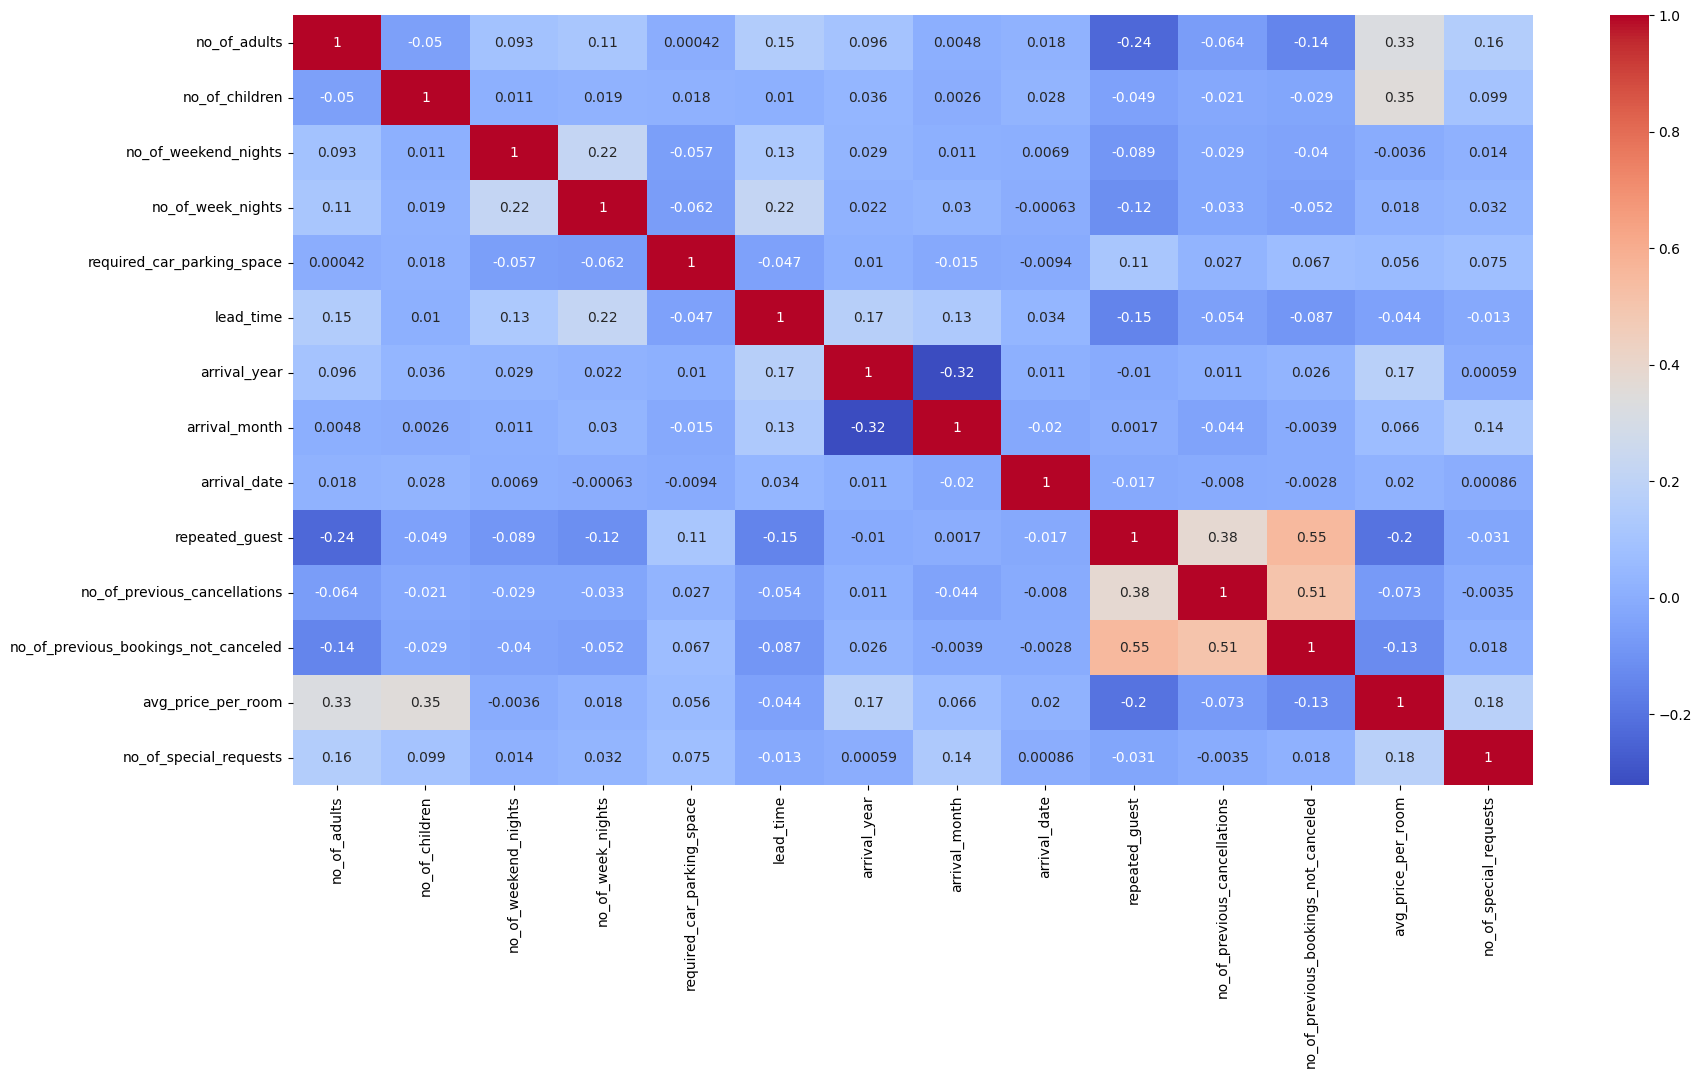

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
df[num_cols].corr()
plt.figure(figsize=(20,10))
sns.heatmap(df[num_cols].corr(), annot=True,cmap='coolwarm')

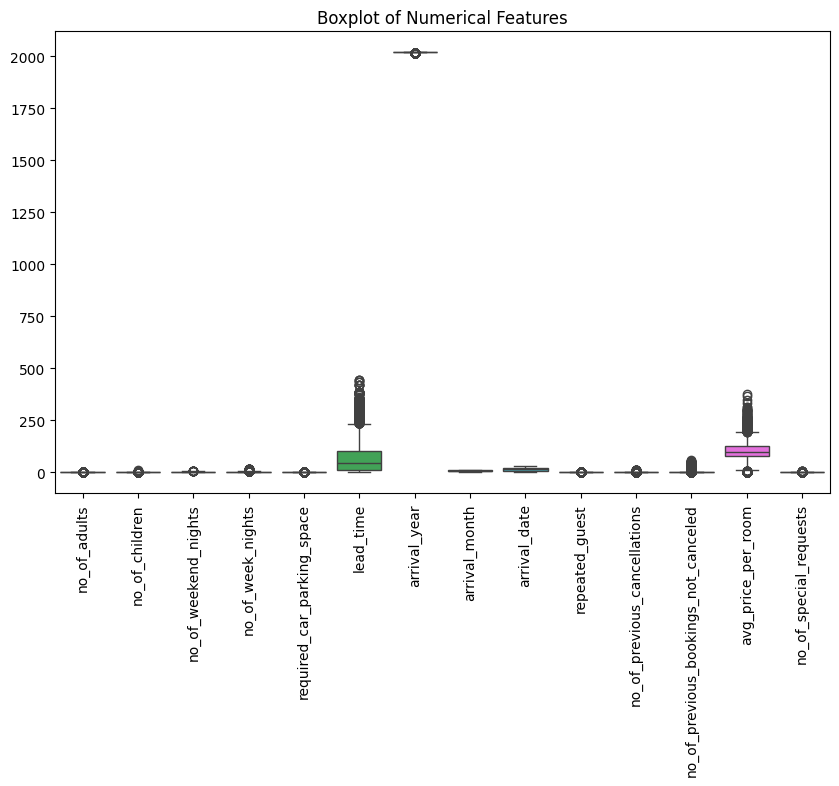

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols] )
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

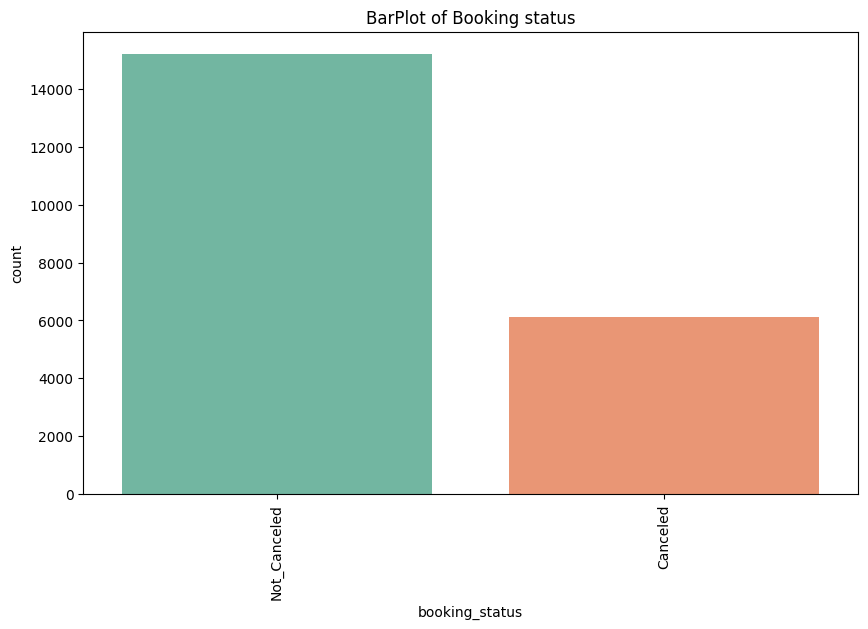

In [22]:
plt.figure(figsize=(10,6))
# sns.countplot(x='booking_status',data=df)
sns.countplot(data=df,x='booking_status', palette='Set2')
plt.xticks(rotation=90)
plt.title('BarPlot of Booking status')
plt.show()

(array([-250.,    0.,  250.,  500.,  750., 1000., 1250., 1500., 1750.,
        2000., 2250.]),
 [Text(-250.0, 0, '−250'),
  Text(0.0, 0, '0'),
  Text(250.0, 0, '250'),
  Text(500.0, 0, '500'),
  Text(750.0, 0, '750'),
  Text(1000.0, 0, '1000'),
  Text(1250.0, 0, '1250'),
  Text(1500.0, 0, '1500'),
  Text(1750.0, 0, '1750'),
  Text(2000.0, 0, '2000'),
  Text(2250.0, 0, '2250')])

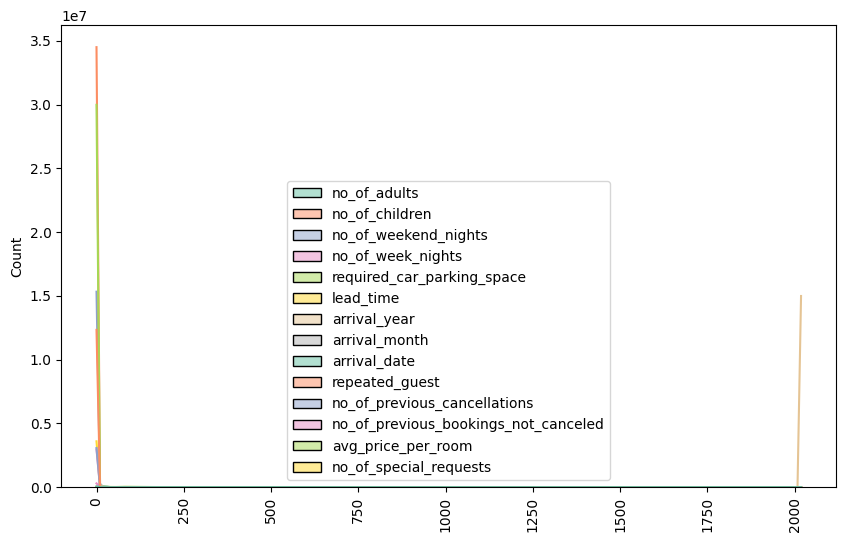

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(df[num_cols],bins=20, kde=True, palette='Set2'
         )
plt.xticks(rotation=90)

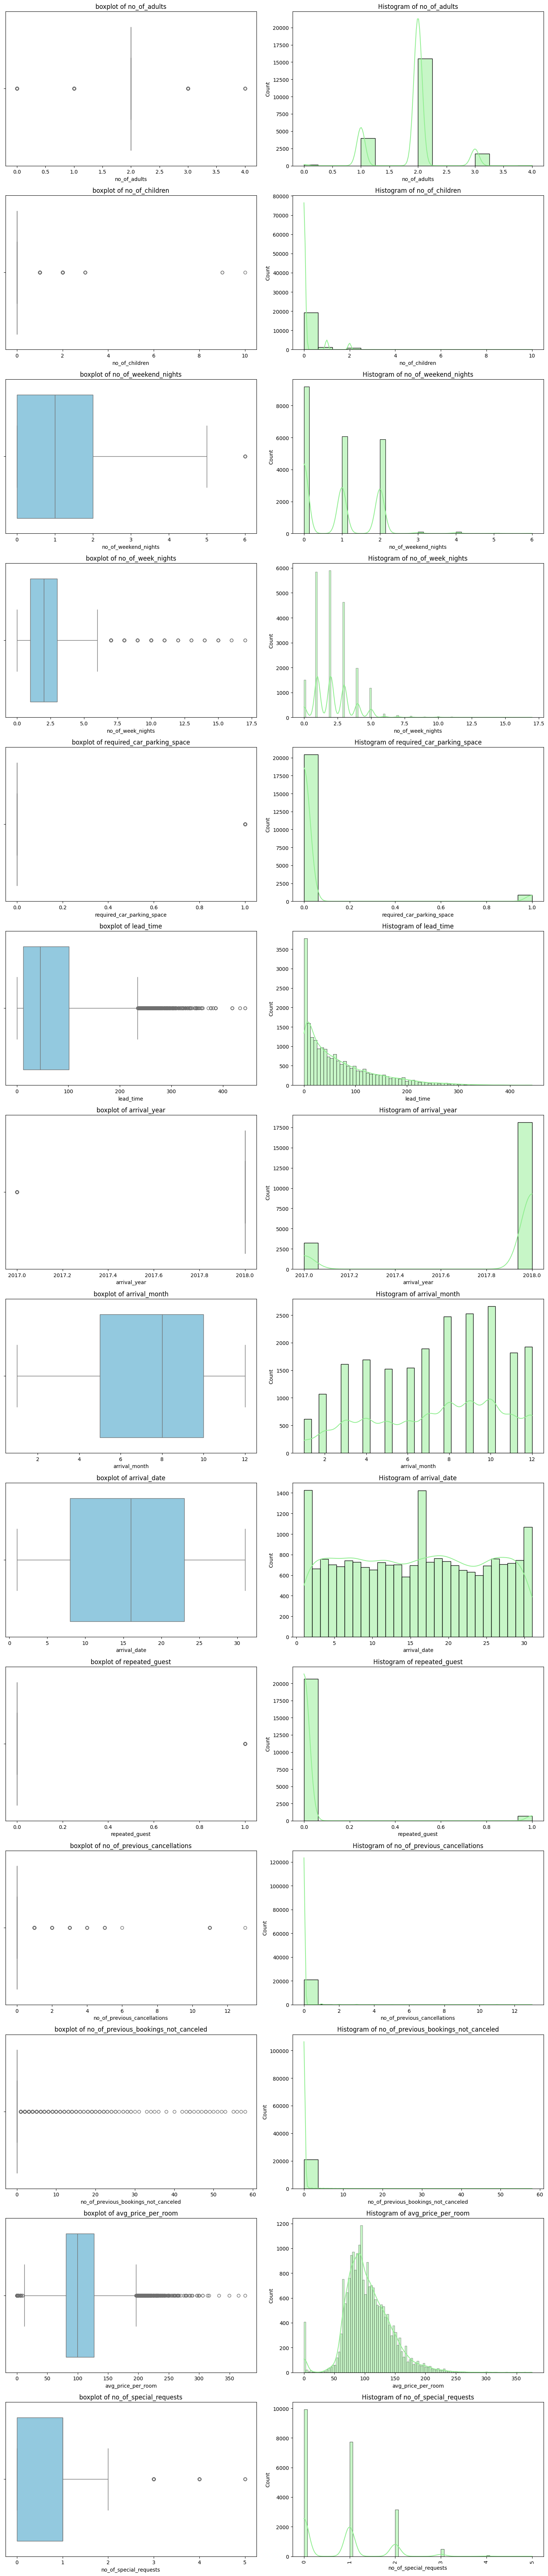

In [24]:
fig,axes= plt.subplots(len(num_cols), 2 , figsize=(15, 5*len(num_cols)))

for i,col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=axes[i,0],color='skyblue')
    ax=axes[i,0].title.set_text(f'boxplot of {col}')
    sns.histplot(x=df[col],ax=axes[i,1],kde=True, color='lightgreen')
    ax = axes[i,1].title.set_text(f'Histogram of {col}')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

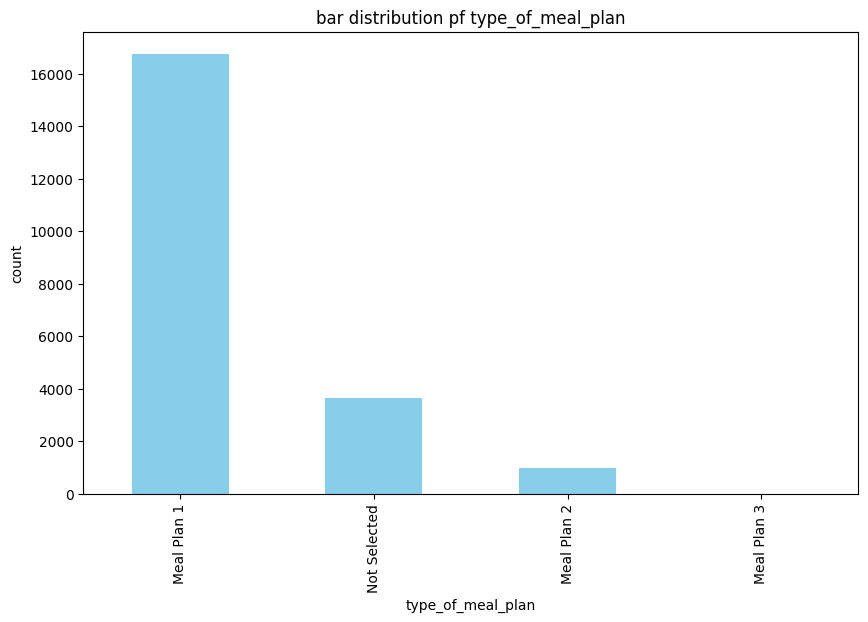

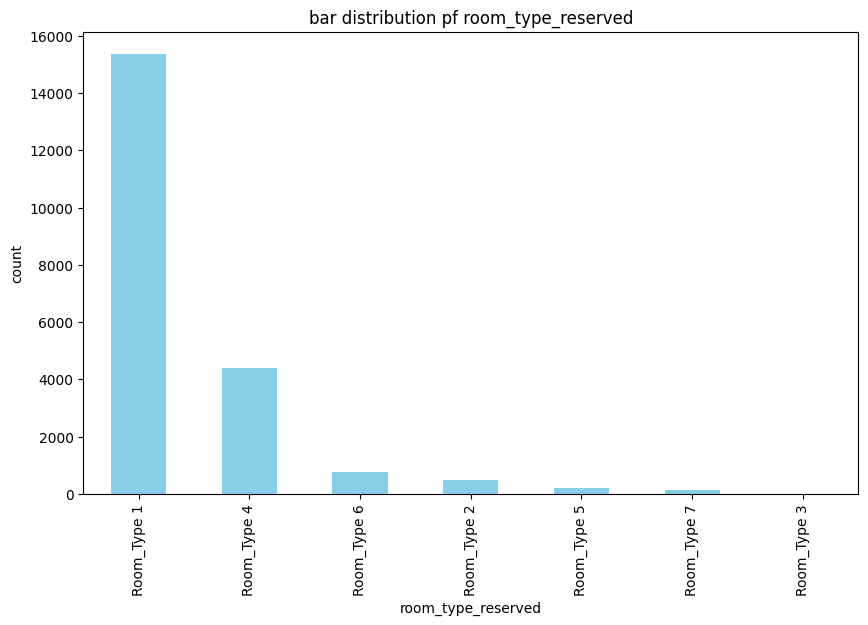

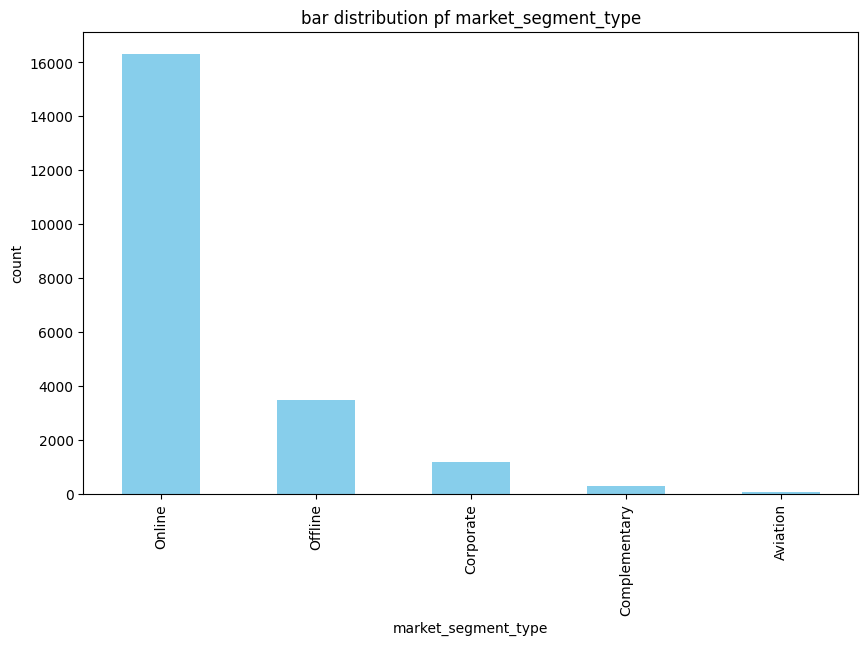

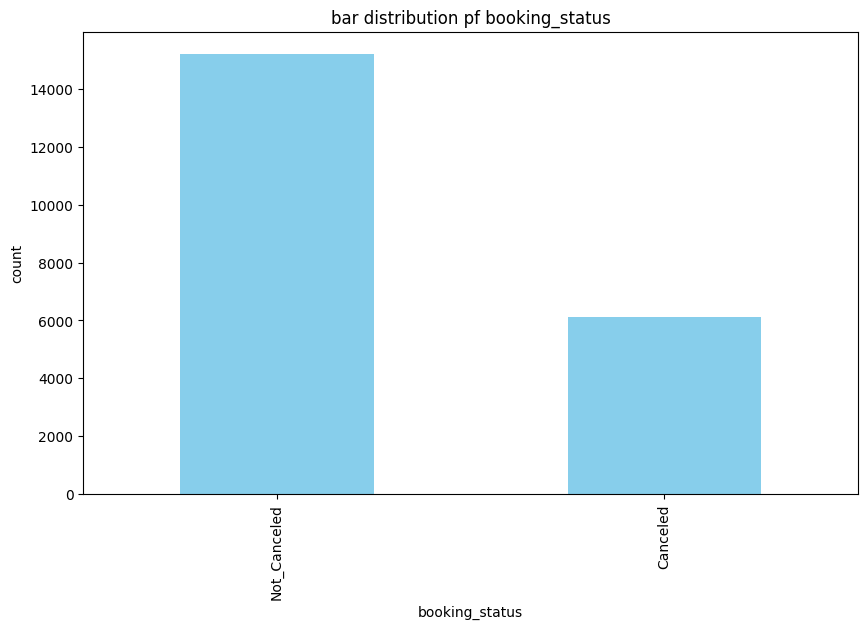

In [25]:
for cat_feature in cat_cols:
    plt.figure(figsize=(10,6))
    data[cat_feature].value_counts().plot(kind='bar',color='skyblue'
    )
    plt.title(f'bar distribution pf {cat_feature}')
    plt.xlabel(cat_feature)
    plt.ylabel('count')
    plt.xticks(rotation=90)




BIVARIATE

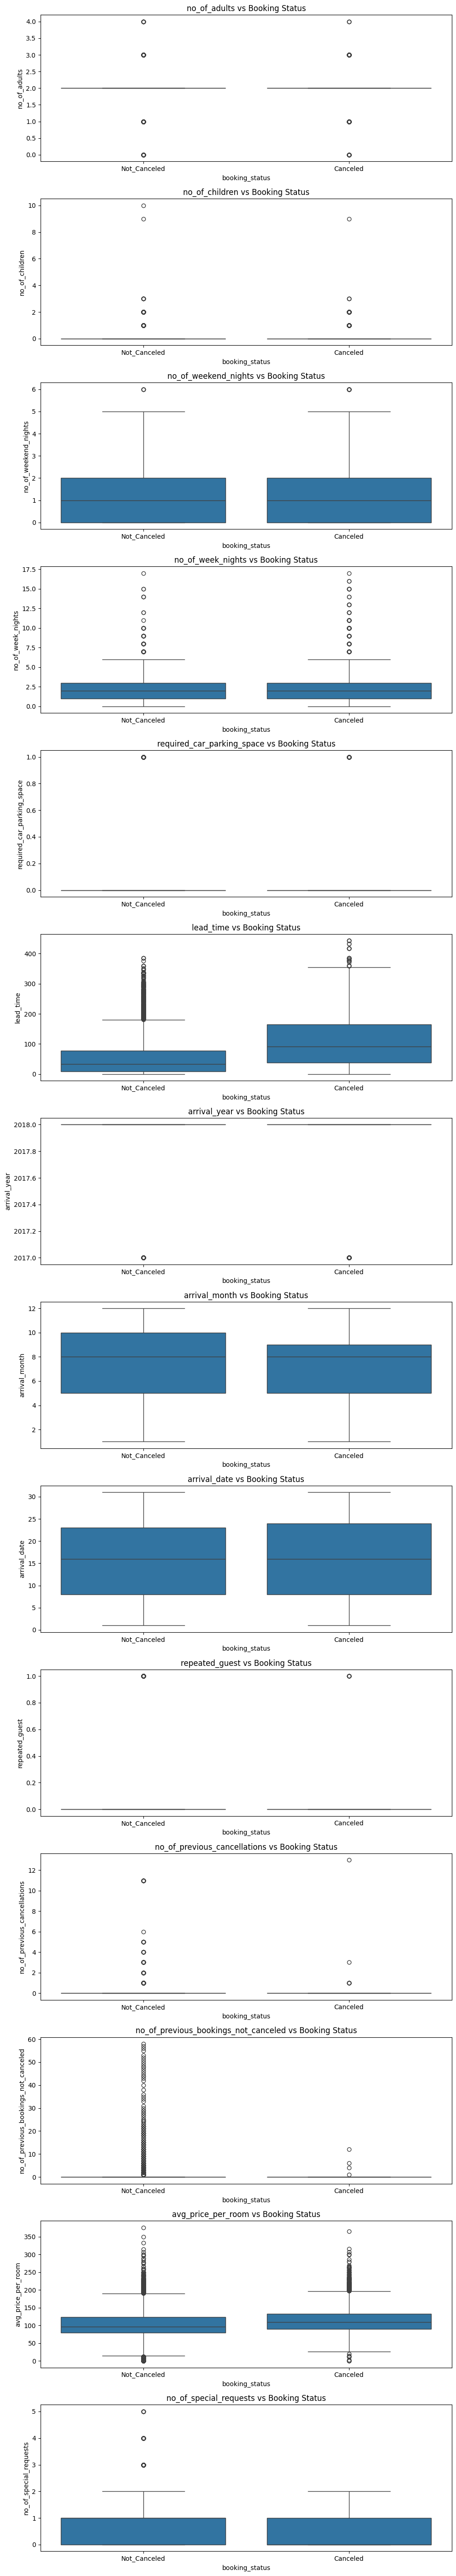

In [26]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, len(num_cols)*4))

for i, col in enumerate(num_cols):
    sns.boxplot(x='booking_status', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Booking Status")

plt.tight_layout()
plt.show()

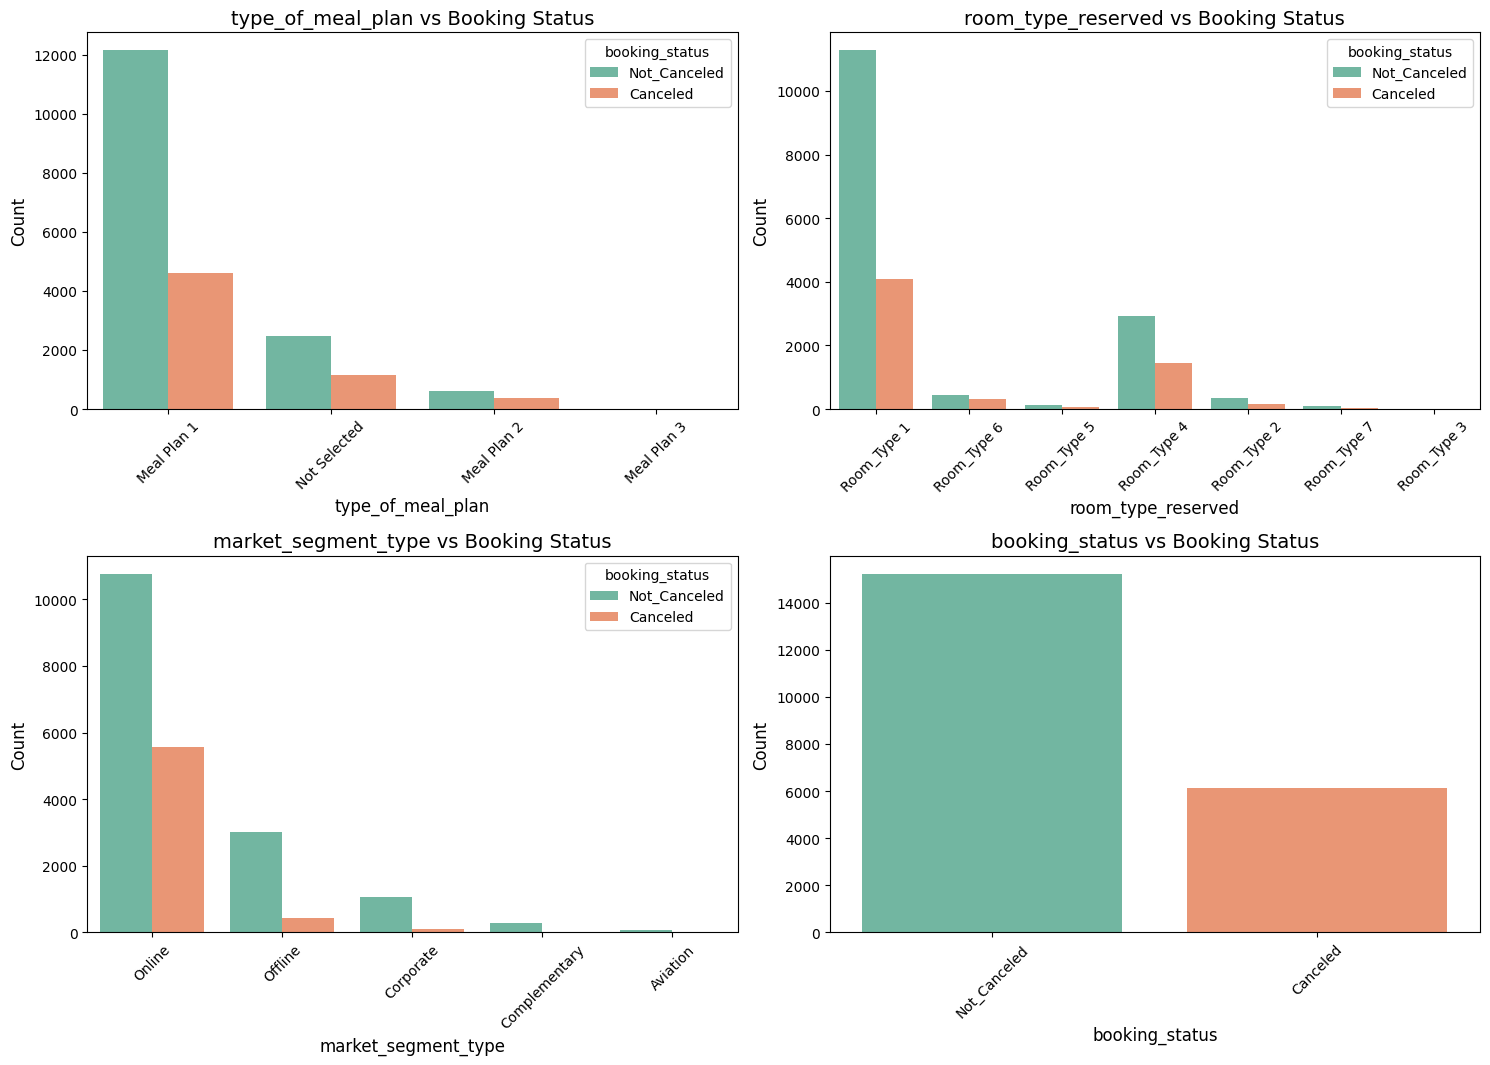

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
# List of categorical features


# Create subplots
n_cols = 2
n_rows = math.ceil(len(cat_cols)/n_cols)
fig, axes = plt.subplots(len(cat_cols), n_rows, figsize=(15, len(cat_cols)*5))

axes=axes.flatten()

for i, cat_feature in enumerate(cat_cols):
    sns.countplot(
        x=cat_feature,
        hue='booking_status',
        data=df,
        palette='Set2',
        ax=axes[i] # draw on this subplot
    )
    axes[i].set_title(f'{cat_feature} vs Booking Status', fontsize=14)
    axes[i].set_xlabel(cat_feature, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()




In [28]:
from sklearn.preprocessing import LabelEncoder, StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




label_encoder =LabelEncoder()
df['booking_status']= label_encoder.fit_transform(df['booking_status'])

In [29]:
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [30]:
class_mapping

{'Canceled': np.int64(0), 'Not_Canceled': np.int64(1)}

In [31]:
standardscaler= StandardScaler()
onehot=OneHotEncoder()

In [32]:
num_cols = df.select_dtypes(include='number').columns.drop('booking_status')
cat_cols = df.select_dtypes(include='object').columns

In [33]:
processor= ColumnTransformer(
    transformers = [
    ('num', standardscaler, num_cols),
    ('cat',onehot, cat_cols)
    ]
)

In [34]:
X= df.drop(columns=['booking_status'])
y=df['booking_status']

In [137]:
!pip install imblearn

     ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
     - -------------------------------------- 10.2/235.4 kB ? eta -:--:--
     - -------------------------------------- 10.2/235.4 kB ? eta -:--:--
     - -------------------------------------- 10.2/235.4 kB ? eta -:--:--
     ---- -------------------------------- 30.7/235.4 kB 187.9 kB/s eta 0:00:02
     ---- -------------------------------- 30.7/235.4 kB 187.9 kB/s eta 0:00:02
     ---- -------------------------------- 30.7/235.4 kB 187.9 kB/s eta 0:00:02
     ------ ------------------------------ 41.0/235.4 kB 115.9 kB/s eta 0:00:02
     --------- --------------------------- 61.4/235.4 kB 156.1 kB/s eta 0:00:02
     ----------- ------------------------- 71.7/235.4 kB 179.1 kB/s eta 0:00:01
     ----------------- ------------------ 112.6/235.4 kB 242.7 kB/s eta 0:00:01
     ----------------- ------------------ 112.6/235.4 kB 242.7 kB/s eta 0:00:01
     ----------------- ------------------ 112.6/235.4 kB 242.7 kB


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# num_col_names = num_cols
# cat_col_names = processor.named_transformers_['cat'].get_feature_names_out(cat_cols)
# # all_col_names = list(num_col_names) + list(cat_col_names)

In [ ]:
# pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
# import pandas as pd

# X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_columns)
# X_train_pca_df['booking_status'] = y_res.reset_index(drop=True)  # add target column


In [35]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA 

pca=PCA(n_components=0.95)
sm= SMOTE(random_state=42)

In [36]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('processor',processor),
    ('smote', sm),
    ('pca',pca),
    ('RM',RandomForestClassifier(n_estimators=100, random_state=42))

])

In [37]:
pipeline.fit(X,y)

,steps,"[('processor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
import pandas as pd

# Load test data
test_df = pd.read_csv('test.csv')

# Separate features and target
X_test = test_df.drop('booking_status', axis=1)  # keep as DataFrame
y_test = test_df['booking_status']

# Encode test labels using the same encoder
y_test = label_encoder.transform(test_df['booking_status'])



In [45]:
# Predict on test set
y_pred = pipeline.predict(X_test)

# Optional: predicted probabilities
y_prob = pipeline.predict_proba(X_test)[:,1]  # probability of class 1


In [46]:
from sklearn.metrics import accuracy_score, mean_absolute_error, recall_score, f1_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1-score
f1 = f1_score(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Full classification report
report = classification_report(y_test, y_pred)

print("Accuracy:", acc)
print("MAE:", mae)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Accuracy: 0.8716747070985528
MAE: 0.12832529290144729
Recall: 0.8851002273196942
F1-score: 0.9019690428556386
Confusion Matrix:
 [[2041  375]
 [ 556 4283]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81      2416
           1       0.92      0.89      0.90      4839

    accuracy                           0.87      7255
   macro avg       0.85      0.86      0.86      7255
weighted avg       0.88      0.87      0.87      7255



In [47]:
import joblib

joblib.dump(pipeline, 'hotel_booking_pipeline.pkl')

print("Pipeline saved successfully!")


Pipeline saved successfully!
